# CarmPom — Model Analysis & 2026 Team Rankings

Visualizes:
- Feature importance from the trained LightGBM model
- Model performance vs KenPom baseline across seasons
- 2026 team rankings by CarmPom Adjusted Efficiency Margin (AdjEM)


## 1. Imports & Setup


In [4]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

# Make sure project root is on the path so we can import our modules
ROOT = Path(".")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from db.database import SessionLocal
from db.models import CarmPomRating, Team
from ml.features import FEATURE_COLS, build_training_features

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130


## 2. Load model & training data


In [5]:
# Load the best trained model
model_path = ROOT / "data" / "models" / "best.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)

print(f"Model type: {type(model).__name__}")

# Build full feature matrix (all seasons)
print("Building feature matrix — takes ~10 seconds...")
features_df = build_training_features(min_season=2003, max_season=2025)
print(f"Loaded {len(features_df):,} tournament games across {features_df['Season'].nunique()} seasons")
print(f"\nFeature columns: {FEATURE_COLS}")


Model type: LGBMClassifier
Building feature matrix — takes ~10 seconds...
Loaded 1,449 tournament games across 22 seasons

Feature columns: ['seed_diff', 'kenpom_rank_diff', 'win_pct_diff', 'pyth_wp_diff', 'adjem_diff', 'efg_diff', 'to_rate_diff', 'or_pct_diff', 'ft_rate_diff']


## 3. Feature Importance

What does the model actually rely on to predict tournament outcomes?


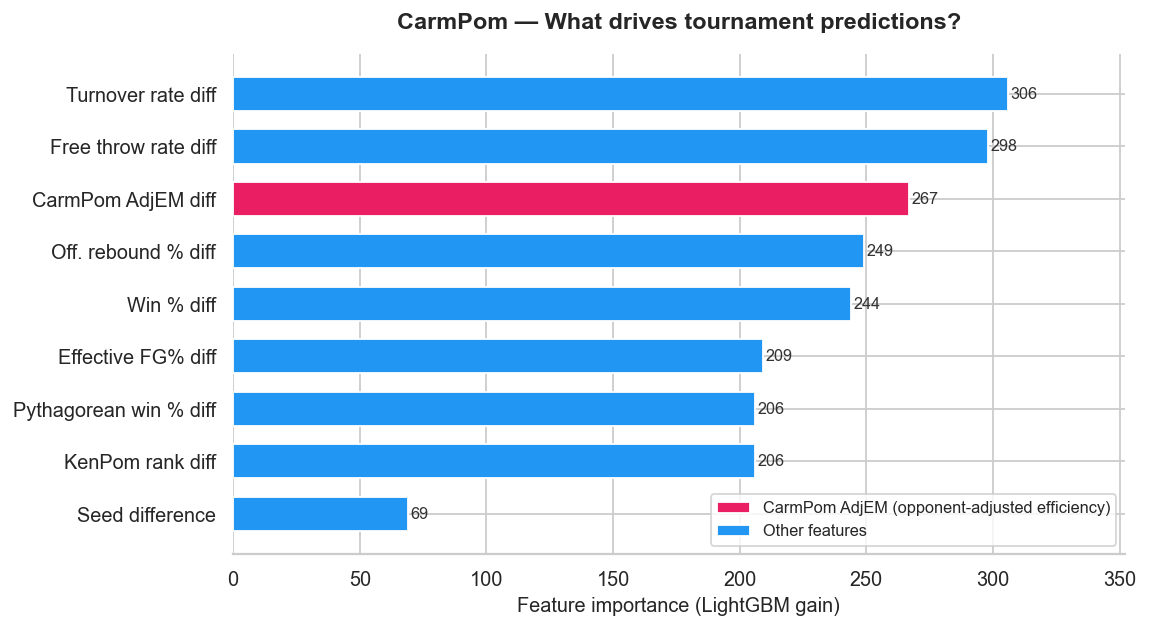

In [6]:
import lightgbm as lgb

# Human-readable feature labels
FEATURE_LABELS = {
    "seed_diff":        "Seed difference",
    "kenpom_rank_diff": "KenPom rank diff",
    "win_pct_diff":     "Win % diff",
    "pyth_wp_diff":     "Pythagorean win % diff",
    "adjem_diff":       "CarmPom AdjEM diff",
    "efg_diff":         "Effective FG% diff",
    "to_rate_diff":     "Turnover rate diff",
    "or_pct_diff":      "Off. rebound % diff",
    "ft_rate_diff":     "Free throw rate diff",
}

# Extract importances — LightGBM exposes feature_importances_ directly
importances = model.feature_importances_
feat_imp = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
    .assign(label=lambda d: d["feature"].map(FEATURE_LABELS))
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2196F3" if f != "adjem_diff" else "#E91E63" for f in feat_imp["feature"]]
bars = ax.barh(feat_imp["label"], feat_imp["importance"], color=colors, edgecolor="white", height=0.65)

# Annotate bar values
for bar, val in zip(bars, feat_imp["importance"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=9, color="#333")

ax.set_xlabel("Feature importance (LightGBM gain)", fontsize=11)
ax.set_title("CarmPom — What drives tournament predictions?", fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, feat_imp["importance"].max() * 1.15)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E91E63", label="CarmPom AdjEM (opponent-adjusted efficiency)"),
    Patch(facecolor="#2196F3", label="Other features"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


## 4. Model Performance — CarmPom vs KenPom Baseline

Log-loss by model on the 2025 holdout season. Lower is better. The dashed line is the KenPom baseline.


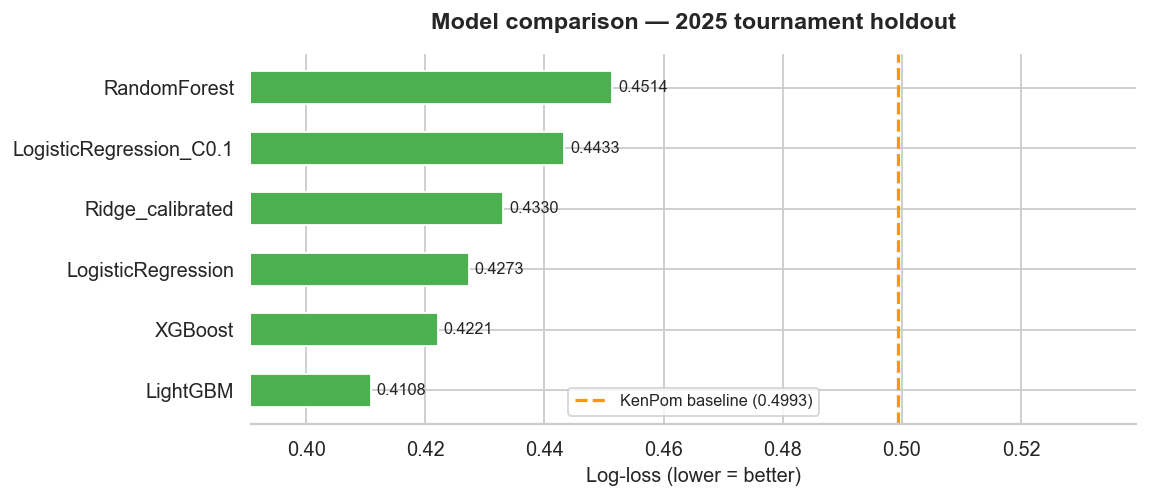

In [8]:
# Load experiment history — each line is one training run
exp_path = ROOT / "data" / "experiments.jsonl"
import json

runs = [json.loads(l) for l in exp_path.read_text().splitlines() if l.strip()]

# Flatten nested "metrics" dict into top-level columns
runs_flat = [{**{k: v for k, v in r.items() if k != "metrics"}, **r.get("metrics", {})} for r in runs]
exp_df = pd.DataFrame(runs_flat)

# Keep only 2025 holdout results (most recent full-feature run per model)
season_runs = exp_df[exp_df["test_season"] == 2025].copy()
# One row per model: keep the best (lowest log_loss) run
best_per_model = (
    season_runs.sort_values("log_loss")
    .drop_duplicates(subset="model", keep="first")
    .sort_values("log_loss")
)

kenpom_ll = best_per_model.loc[best_per_model["model"] == "KenPom_baseline", "log_loss"].iloc[0]
plot_df = best_per_model[best_per_model["model"] != "KenPom_baseline"].copy()

fig, ax = plt.subplots(figsize=(9, 4))
palette = ["#4CAF50" if ll < kenpom_ll else "#F44336" for ll in plot_df["log_loss"]]
bars = ax.barh(plot_df["model"], plot_df["log_loss"], color=palette, edgecolor="white", height=0.55)

# KenPom baseline reference line
ax.axvline(kenpom_ll, color="#FF9800", linewidth=1.8, linestyle="--", label=f"KenPom baseline ({kenpom_ll:.4f})")

for bar, val in zip(bars, plot_df["log_loss"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9)

ax.set_xlabel("Log-loss (lower = better)", fontsize=11)
ax.set_title("Model comparison — 2025 tournament holdout", fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(plot_df["log_loss"].min() - 0.02, kenpom_ll + 0.04)
ax.legend(fontsize=9)
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 5. 2026 Team Rankings

CarmPom's full D1 rankings for the 2026 season, sorted by Adjusted Efficiency Margin (AdjEM). This is the headline metric — the gap in points per 100 possessions between a team's offense and defense, after accounting for strength of schedule.


In [22]:

# Pull 2026 ratings + team names from the database
with SessionLocal() as session:
    rows = (
        session.query(
            CarmPomRating.rank,
            Team.name,
            Team.conference,
            CarmPomRating.adjem,
            CarmPomRating.adjo,
            CarmPomRating.adjd,
            CarmPomRating.adjt,
            CarmPomRating.luck,
            CarmPomRating.sos,
            CarmPomRating.wins,
            CarmPomRating.losses,
        )
        .join(Team, Team.id == CarmPomRating.team_id)
        .filter(CarmPomRating.season == 2026)
        .order_by(CarmPomRating.rank)
        .all()
    )

rankings = pd.DataFrame(rows, columns=["Rank", "Team", "Conf", "AdjEM", "AdjO", "AdjD", "AdjT", "Luck", "SOS", "W", "L"])
rankings["Record"] = rankings["W"].astype(str) + "-" + rankings["L"].astype(str)
rankings["Conf"] = rankings["Conf"].str.removesuffix(" Conference")

# Compute national rank for each metric across all rated teams
# ascending=True means lower value = rank 1 (used for AdjD where lower is better)
rank_cfg = {
    "AdjEM": False,
    "AdjO":  False,
    "AdjD":  True,   # lower allowed pts = better
    "AdjT":  False,
    "Luck":  False,
    "SOS":   False,
}
for col, asc in rank_cfg.items():
    rankings[f"{col}_nr"] = rankings[col].rank(ascending=asc, method="min").astype(int)

print(f"Total teams rated: {len(rankings)}")

top50 = rankings.head(50).copy()

# Build display DataFrame with "value  rank" text in each metric cell,
# matching KenPom's compact inline-rank style.
display_df = top50[["Rank", "Team", "Conf", "Record"]].copy()
display_df["AdjEM"] = top50.apply(lambda r: f"{r['AdjEM']:+.2f}  {r['AdjEM_nr']}", axis=1)
display_df["AdjO"]  = top50.apply(lambda r: f"{r['AdjO']:.2f}  {r['AdjO_nr']}", axis=1)
display_df["AdjD"]  = top50.apply(lambda r: f"{r['AdjD']:.2f}  {r['AdjD_nr']}", axis=1)
display_df["AdjT"]  = top50.apply(lambda r: f"{r['AdjT']:.1f}  {r['AdjT_nr']}", axis=1)
display_df["Luck"]  = top50.apply(lambda r: f"{r['Luck']:+.3f}  {r['Luck_nr']}", axis=1)
display_df["SOS"]   = top50.apply(lambda r: f"{r['SOS']:+.2f}  {r['SOS_nr']}", axis=1)

_TABLE_STYLES = [
    # Header: dark navy background, white text
    {"selector": "thead th", "props": [
        ("background-color", "#1e2d40"),
        ("color", "white"),
        ("font-weight", "600"),
        ("padding", "9px 14px"),
        ("font-size", "12px"),
        ("letter-spacing", "0.3px"),
        ("border-bottom", "2px solid #344d66"),
    ]},
    # Index column header
    {"selector": "thead th.index_name", "props": [
        ("background-color", "#1e2d40"),
    ]},
    # Even rows: white
    {"selector": "tbody tr:nth-child(even) td", "props": [
        ("background-color", "#ffffff"),
    ]},
    # Odd rows: very light gray
    {"selector": "tbody tr:nth-child(odd) td", "props": [
        ("background-color", "#f4f6f8"),
    ]},
    # Row hover: subtle blue tint (overrides zebra for non-gradient cols)
    {"selector": "tbody tr:hover td", "props": [
        ("background-color", "#ddeeff !important"),
    ]},
    # All data cells: consistent padding, font, muted border
    {"selector": "td", "props": [
        ("padding", "7px 14px"),
        ("font-size", "13px"),
        ("border-bottom", "1px solid #e3e7ec"),
        ("border-right", "1px solid #e3e7ec"),
        ("font-family", "system-ui, -apple-system, sans-serif"),
    ]},
    # Table container
    {"selector": "", "props": [
        ("border-collapse", "collapse"),
        ("font-family", "system-ui, -apple-system, sans-serif"),
        ("box-shadow", "0 2px 10px rgba(0,0,0,0.09)"),
    ]},
    # Caption (shown below the table)
    {"selector": "caption", "props": [
        ("caption-side", "bottom"),
        ("font-size", "11px"),
        ("color", "#888"),
        ("padding-top", "8px"),
        ("text-align", "left"),
        ("font-family", "system-ui, -apple-system, sans-serif"),
    ]},
]

# gmap= passes raw numeric values for gradient coloring even though cells display strings.
# Zebra/hover styling applies to the identity cols; gradient cols get their own bg colors.
display_df.style \
    .background_gradient(subset=["AdjEM"], cmap="RdYlGn",   gmap=top50["AdjEM"].values) \
    .background_gradient(subset=["AdjO"],  cmap="Greens",   gmap=top50["AdjO"].values) \
    .background_gradient(subset=["AdjD"],  cmap="RdYlGn_r", gmap=top50["AdjD"].values) \
    .background_gradient(subset=["AdjT"],  cmap="RdBu_r",   gmap=top50["AdjT"].values) \
    .background_gradient(subset=["Luck"],  cmap="RdYlGn",   gmap=top50["Luck"].values) \
    .background_gradient(subset=["SOS"],   cmap="RdYlGn",   gmap=top50["SOS"].values) \
    .set_table_styles(_TABLE_STYLES) \
    .hide(axis="index") \
    .set_caption(
        "CarmPom 2026 — Top 50 Teams  |  Each cell: value  national_rank  |  "
        "AdjEM = pts/100 margin  |  AdjO = off. eff.  |  AdjD = def. eff. (lower=better)  |  "
        "AdjT = tempo (red=fast, blue=slow)  |  Luck = actual W% − expected W%"
    )


Total teams rated: 365


Rank,Team,Conf,Record,AdjEM,AdjO,AdjD,AdjT,Luck,SOS
1,Michigan Wolverines,Big Ten,29-2,+46.83 1,133.59 3,86.76 2,73.0 22,+0.009 177,+20.70 2
2,Duke Blue Devils,Atlantic Coast,30-2,+46.21 2,132.44 4,86.23 1,66.8 294,-0.005 198,+17.11 16
3,Arizona Wildcats,Big 12,30-2,+42.17 3,129.19 8,87.02 3,71.5 53,+0.019 149,+17.24 14
4,Illinois Fighting Illini,Big Ten,24-7,+40.52 4,134.98 1,94.45 18,67.4 271,-0.110 348,+16.98 18
5,Florida Gators,Southeastern,25-6,+39.52 5,128.65 9,89.14 7,71.5 51,-0.081 322,+18.01 10
6,Houston Cougars,Big 12,27-5,+38.58 6,127.15 17,88.57 4,64.7 356,-0.052 292,+15.80 23
7,Iowa State Cyclones,Big 12,27-6,+38.47 7,127.48 15,89.01 5,68.1 229,-0.100 343,+14.38 44
8,Purdue Boilermakers,Big Ten,24-8,+37.46 8,134.68 2,97.22 33,66.0 324,-0.077 315,+19.14 6
9,Gonzaga Bulldogs,West Coast,30-3,+35.37 9,124.50 29,89.13 6,70.3 112,-0.022 240,+8.65 82
10,UConn Huskies,Big East,28-4,+34.48 10,125.64 21,91.16 10,66.4 307,+0.005 186,+14.50 42


## 6. Top 25 Rankings — Visual


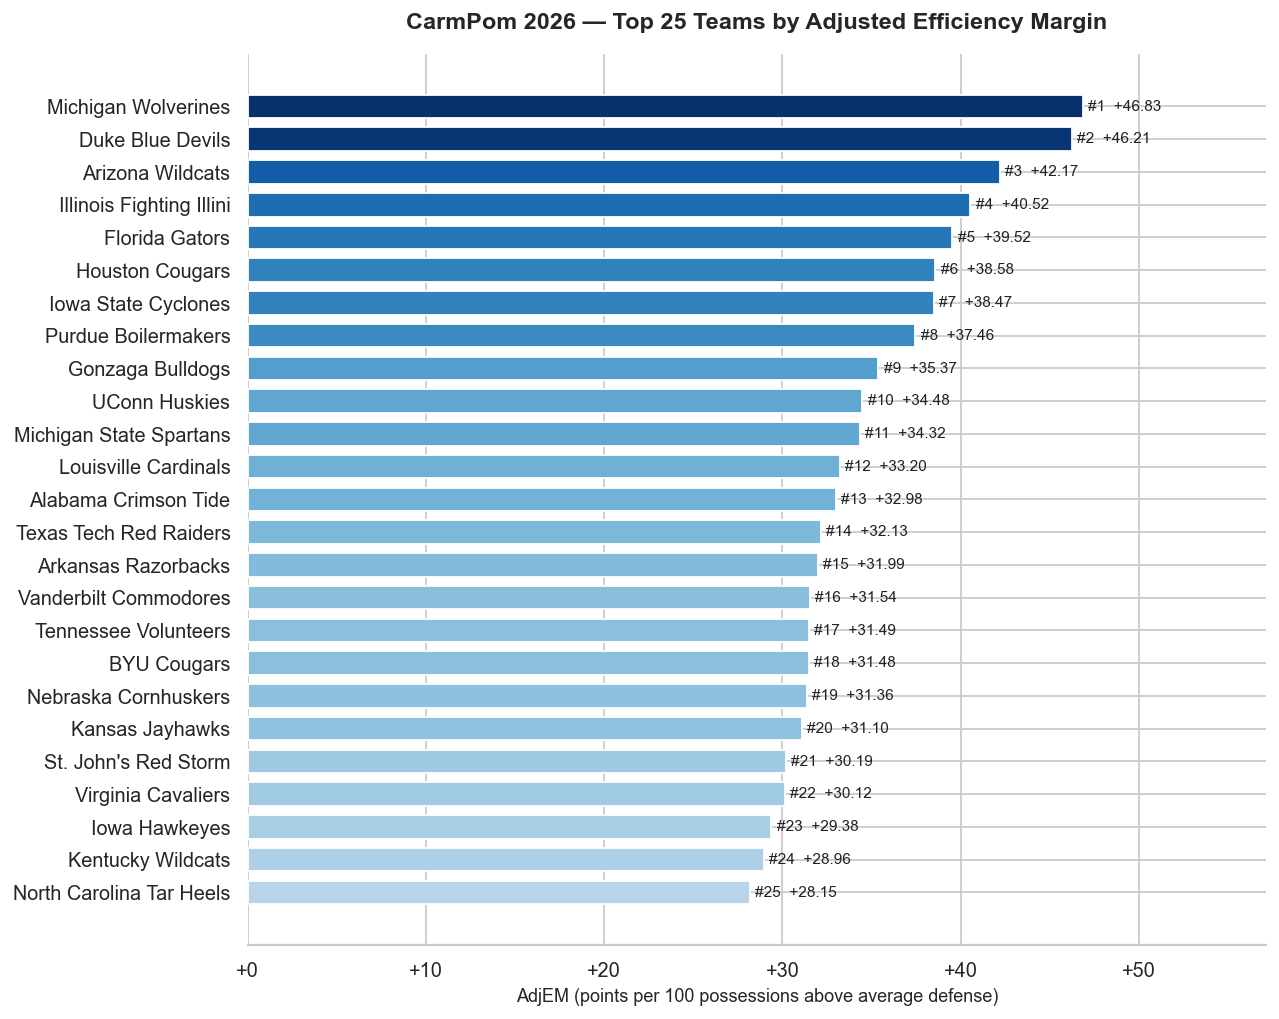

In [13]:
top25 = rankings.head(25).sort_values("AdjEM", ascending=True)

# Color gradient: deeper blue = higher ranked
norm = plt.Normalize(top25["AdjEM"].min(), top25["AdjEM"].max())
colors = plt.cm.Blues(norm(top25["AdjEM"].values) * 0.7 + 0.3)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(top25["Team"], top25["AdjEM"], color=colors, edgecolor="white", height=0.72)

# Annotate with rank and AdjEM value
for bar, (_, row) in zip(bars, top25.iterrows()):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"#{int(row['Rank'])}  {row['AdjEM']:+.2f}",
        va="center", fontsize=8.5, color="#222",
    )

ax.set_xlabel("AdjEM (points per 100 possessions above average defense)", fontsize=10)
ax.set_title("CarmPom 2026 — Top 25 Teams by Adjusted Efficiency Margin",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlim(0, top25["AdjEM"].max() * 1.22)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%+.0f"))
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()


## 7. CarmPom vs KenPom — Biggest Rating Discrepancies

Where does CarmPom disagree most with KenPom? Teams above the line are rated **higher** by CarmPom; teams below are rated **lower**.
AdjEM diff = CarmPom AdjEM − KenPom AdjEM for the most recent shared season.

KenPom 2026 — teams loaded: 307
Teams matched: 263
Top-100 CarmPom teams matched: 83


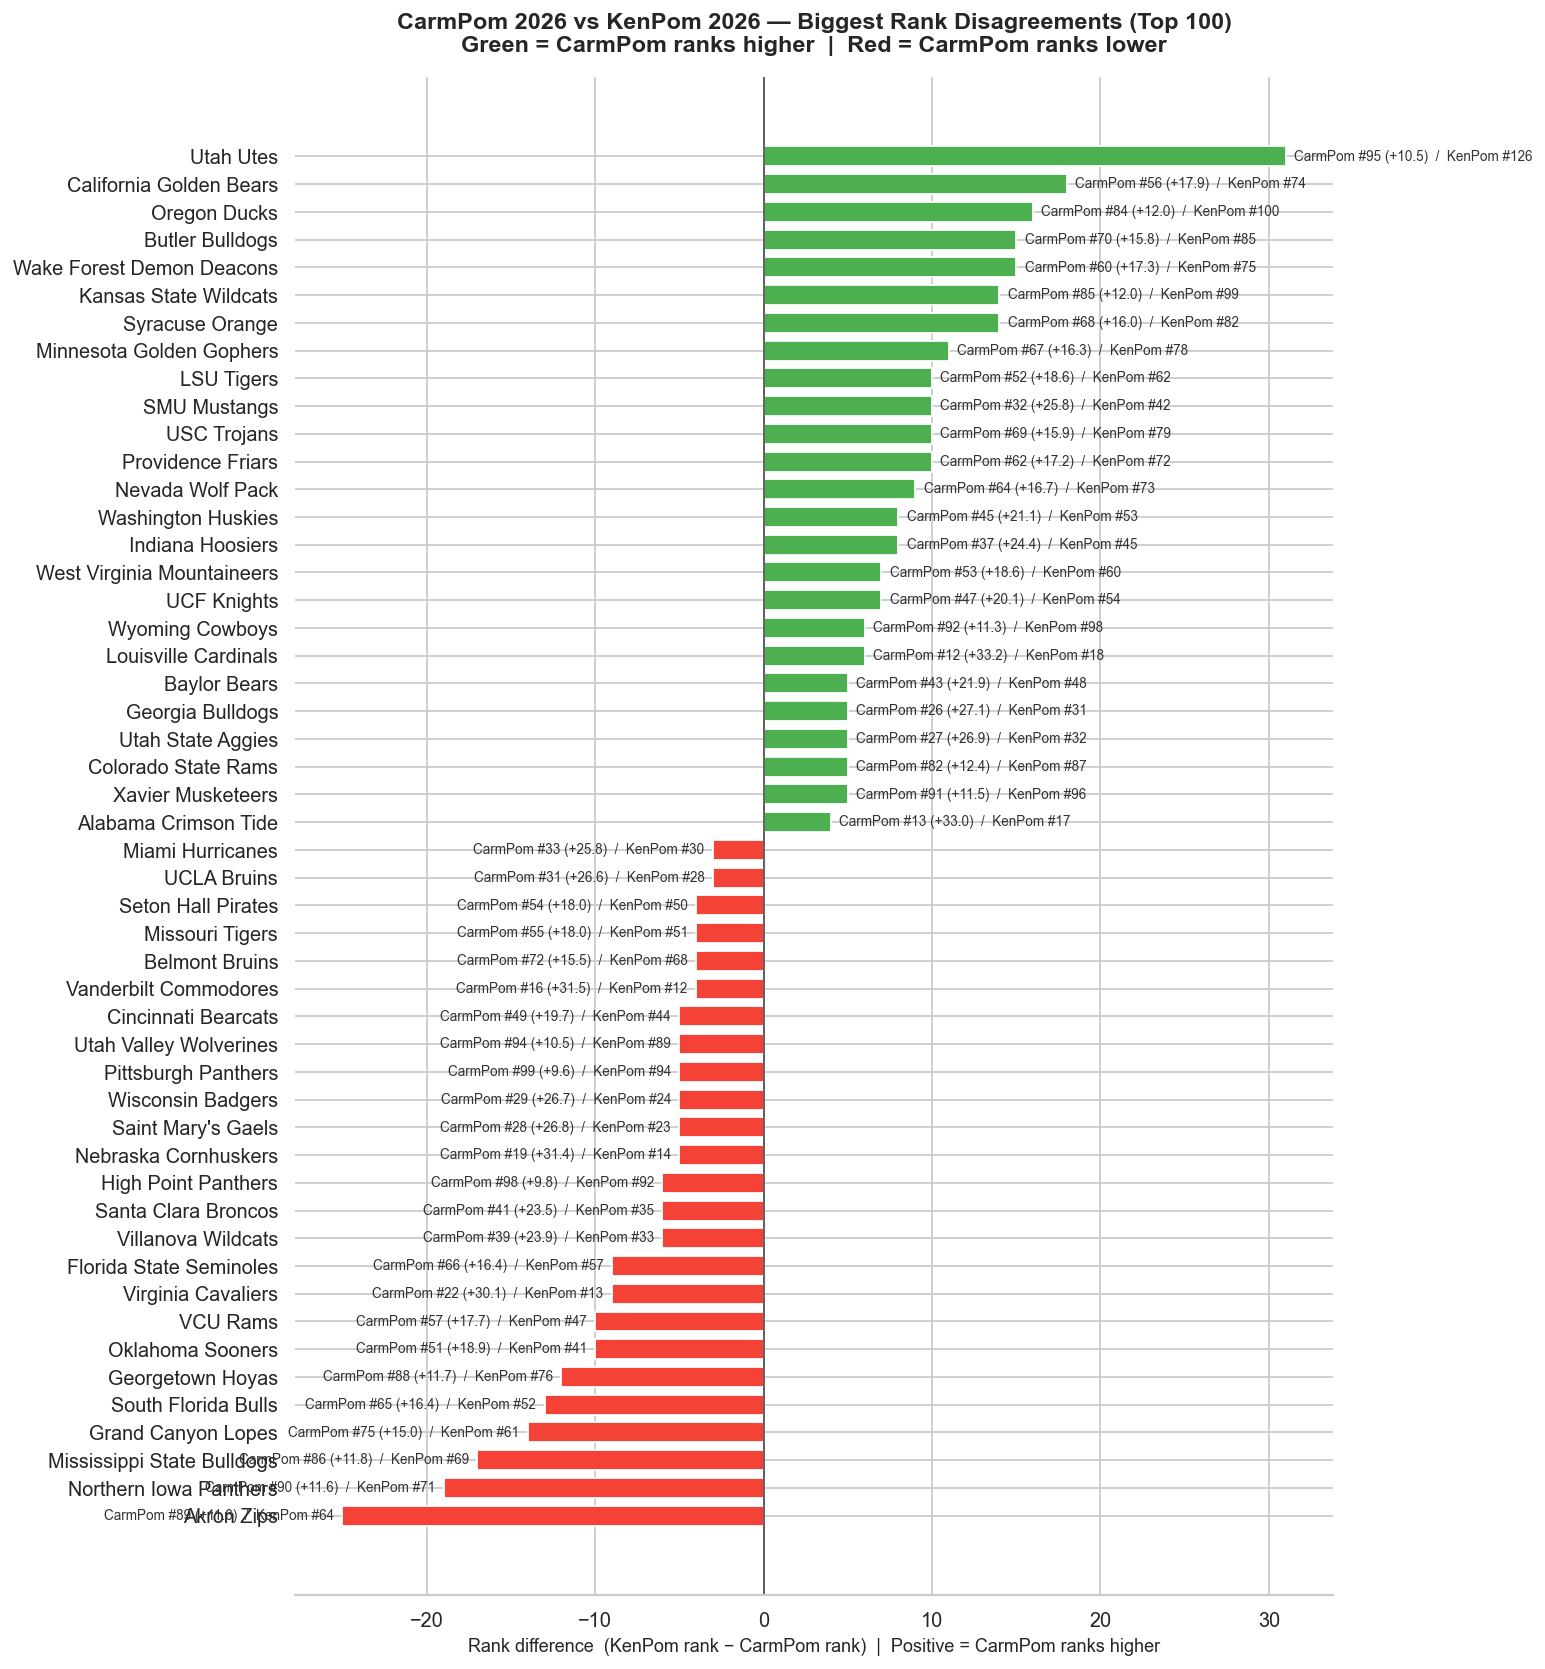


Top 10 — CarmPom ranks HIGHER than KenPom (top 100):
                     Team           Conf  cp_rank  cp_adjem  kp_rank  rank_diff
                Utah Utes         Big 12       95   10.4830      126         31
  California Golden Bears Atlantic Coast       56   17.9468       74         18
             Oregon Ducks        Big Ten       84   12.0495      100         16
Wake Forest Demon Deacons Atlantic Coast       60   17.2997       75         15
          Butler Bulldogs       Big East       70   15.7969       85         15
          Syracuse Orange Atlantic Coast       68   16.0384       82         14
    Kansas State Wildcats         Big 12       85   12.0049       99         14
 Minnesota Golden Gophers        Big Ten       67   16.3438       78         11
             SMU Mustangs Atlantic Coast       32   25.8201       42         10
               LSU Tigers   Southeastern       52   18.6283       62         10

Top 10 — CarmPom ranks LOWER than KenPom (top 100):
             

In [ ]:

# Load pre-built KenPom 2026 ranks derived from data/kaggle/KenPom2026.csv
# (scraped from kenpom.com; name-matched to CarmPom db_team_ids via team_id_map.csv)
# Columns: kp_name, kp_rank, db_team_id
kp_ranks = pd.read_csv(ROOT / "data" / "kenpom2026_ranks.csv")
print(f"KenPom 2026 — teams loaded: {len(kp_ranks)}")

# Pull CarmPom 2026 ranks + metadata from DB
with SessionLocal() as session:
    cp_rows = (
        session.query(CarmPomRating.team_id, CarmPomRating.rank)
        .filter(CarmPomRating.season == 2026)
        .order_by(CarmPomRating.rank)
        .all()
    )

cp_ids = pd.DataFrame(cp_rows, columns=["team_id", "cp_rank"])
cp_ids["team_id"] = cp_ids["team_id"].astype(int)

# Attach team name/conf/AdjEM from the already-loaded `rankings` DataFrame
cp_full = cp_ids.merge(
    rankings[["Rank", "Team", "Conf", "AdjEM"]].rename(columns={"Rank": "cp_rank", "AdjEM": "cp_adjem"}),
    on="cp_rank",
)

# Join CarmPom with KenPom ranks on db_team_id
compare = (
    cp_full
    .merge(kp_ranks[["db_team_id", "kp_rank", "kp_name"]], left_on="team_id", right_on="db_team_id", how="inner")
    .drop_duplicates(subset="team_id")
)
print(f"Teams matched: {len(compare)}")

# rank_diff > 0: CarmPom ranks HIGHER (lower number), KenPom has them lower
compare["rank_diff"] = compare["kp_rank"] - compare["cp_rank"]

# Focus on CarmPom top 100
top100 = compare[compare["cp_rank"] <= 100].copy()
print(f"Top-100 CarmPom teams matched: {len(top100)}")

n = 25
top_higher = top100.nlargest(n, "rank_diff")
top_lower  = top100.nsmallest(n, "rank_diff")
plot_disc  = pd.concat([top_higher, top_lower]).drop_duplicates(subset="team_id").sort_values("rank_diff")

bar_colors = ["#4CAF50" if v > 0 else "#F44336" for v in plot_disc["rank_diff"]]

fig, ax = plt.subplots(figsize=(12, 13))
bars = ax.barh(plot_disc["Team"], plot_disc["rank_diff"], color=bar_colors, edgecolor="white", height=0.72)

for bar, (_, row) in zip(bars, plot_disc.iterrows()):
    x = bar.get_width()
    label = f"CarmPom #{int(row['cp_rank'])} ({row['cp_adjem']:+.1f})  /  KenPom #{int(row['kp_rank'])}"
    ax.text(
        x + (0.5 if x >= 0 else -0.5),
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center", ha="left" if x >= 0 else "right",
        fontsize=7.5, color="#333",
    )

ax.axvline(0, color="#555", linewidth=1.0)
ax.set_xlabel("Rank difference  (KenPom rank − CarmPom rank)  |  Positive = CarmPom ranks higher", fontsize=10)
ax.set_title(
    "CarmPom 2026 vs KenPom 2026 — Biggest Rank Disagreements (Top 100)\n"
    "Green = CarmPom ranks higher  |  Red = CarmPom ranks lower",
    fontsize=13, fontweight="bold", pad=14,
)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

cols = ["Team", "Conf", "cp_rank", "cp_adjem", "kp_rank", "rank_diff"]
print(f"\nTop 10 — CarmPom ranks HIGHER than KenPom (top 100):")
print(top100.nlargest(10, "rank_diff")[cols].to_string(index=False))
print(f"\nTop 10 — CarmPom ranks LOWER than KenPom (top 100):")
print(top100.nsmallest(10, "rank_diff")[cols].to_string(index=False))
